In [14]:
import json
import os
import re
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

In [15]:
def classify_model(model_path: str) -> str:
    """Classify model into: gemma, vanilla, scoped, or recovered."""
    if "google/gemma-2-9b-it" in model_path:
        return "gemma"
    if "vanilla" in model_path and re.search(r"checkpoint-\d+", model_path):
        return "vanilla"
    if "ultrachat" in model_path:
        return "scoped"
    if "layer_31_width_16k_canonical" in model_path and "ultrachat" not in model_path:
        return "recovered"
    return "unknown"

In [16]:
# Load all results
results_dir = Path("math_eval_results")
results = []

def get_dataset_trained_on(model_path: str) -> str:
    if "google/gemma-2-9b-it" in model_path:
        assert not "/gsm8k/" in model_path, "Model path contains both gsm8k and numinamath"
        assert not "/numinamath/" in model_path, "Model path contains both gsm8k and numinamath"
        assert not "/ultrachat/" in model_path, "Model path contains both gsm8k and numinamath"
        return None
    if "/ultrachat/" in model_path:
        assert not "/gsm8k/" in model_path, "Model path contains both gsm8k and numinamath"
        assert not "/numinamath/" in model_path, "Model path contains both gsm8k and numinamath"
        return None
    if "/gsm8k/" in model_path:
        assert not "/numinamath/" in model_path, "Model path contains both gsm8k and numinamath"
        return "gsm8k"
    if "/numinamath/" in model_path:
        assert not "/gsm8k/" in model_path, "Model path contains both gsm8k and numinamath"
        return "numinamath"
    return "unknown"

for json_file in results_dir.glob("*.json"):
    with open(json_file) as f:
        data = json.load(f)
    
    model_path = data["config"]["model"]
    dataset_evaluted_on = data["statistics"]["dataset"] # dataset its EVALUATED on
    dataset_trained_on = get_dataset_trained_on(model_path)
    accuracy = data["statistics"]["accuracy"]
    category = classify_model(model_path)
    
    results.append({
        "model_path": model_path,
        "accuracy": accuracy,
        "category": category,
        "dataset_trained_on": dataset_trained_on,
        "dataset_evaluted_on": dataset_evaluted_on,
    })
    dataset_trained_on_str = dataset_trained_on if dataset_trained_on else "N/A"
    dataset_evaluted_on_str = dataset_evaluted_on
    print(f"{dataset_trained_on_str:12} | {dataset_evaluted_on_str:12} | {category:10} | {accuracy:.3f} | {model_path[:]}")

numinamath   | gsm8k        | recovered  | 0.156 | /mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b/numinamath/layer_31_width_16k_canonical_h0.0001_dbbdb4bd58/checkpoint-4000
numinamath   | numinamath   | vanilla    | 0.188 | /mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b/numinamath/vanilla/checkpoint-4000
numinamath   | gsm8k        | vanilla    | 0.844 | /mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b/numinamath/vanilla/checkpoint-4000
numinamath   | numinamath   | recovered  | 0.094 | /mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b/numinamath/layer_31_width_16k_canonical_h0.0001_dbbdb4bd58/checkpoint-4000
gsm8k        | numinamath   | vanilla    | 0.188 | /mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b/gsm8k/vanilla/checkpoint-4000
gsm8k        | gsm8k        | vanilla    | 0.812 | /mnt/align4_drive2/adrianoh/git/SAEScoping/experiments/outputs_gemma9b/gsm8k/vanilla/chec

In [17]:
# Create group labels combining training dataset + model category
def get_group_label(dataset_trained_on, category):
    """Get group label for coloring and legend."""
    if category == "gemma":
        return "Gemma (base)"
    if category == "scoped":
        return "Scoped (ultrachat)"
    if dataset_trained_on == "gsm8k":
        if category == "vanilla":
            return "GSM8K + SFT"
        elif category == "recovered":
            return "GSM8K + Recovered"
    elif dataset_trained_on == "numinamath":
        if category == "vanilla":
            return "NuminaMath + SFT"
        elif category == "recovered":
            return "NuminaMath + Recovered"
    return f"{dataset_trained_on} + {category}"

# Add group labels to results
for r in results:
    r["group"] = get_group_label(r["dataset_trained_on"], r["category"])

# Define colors for each group
GROUP_COLORS = {
    "GSM8K + SFT": "#1f77b4",           # blue
    "GSM8K + Recovered": "#aec7e8",      # light blue
    "NuminaMath + SFT": "#ff7f0e",       # orange
    "NuminaMath + Recovered": "#ffbb78", # light orange
    "Gemma (base)": "#2ca02c",           # green
    "Scoped (ultrachat)": "#d62728",     # red
}

# Define display order for groups
GROUP_ORDER = [
    "Gemma (base)",
    "Scoped (ultrachat)",
    "GSM8K + SFT",
    "GSM8K + Recovered",
    "NuminaMath + SFT",
    "NuminaMath + Recovered",
]

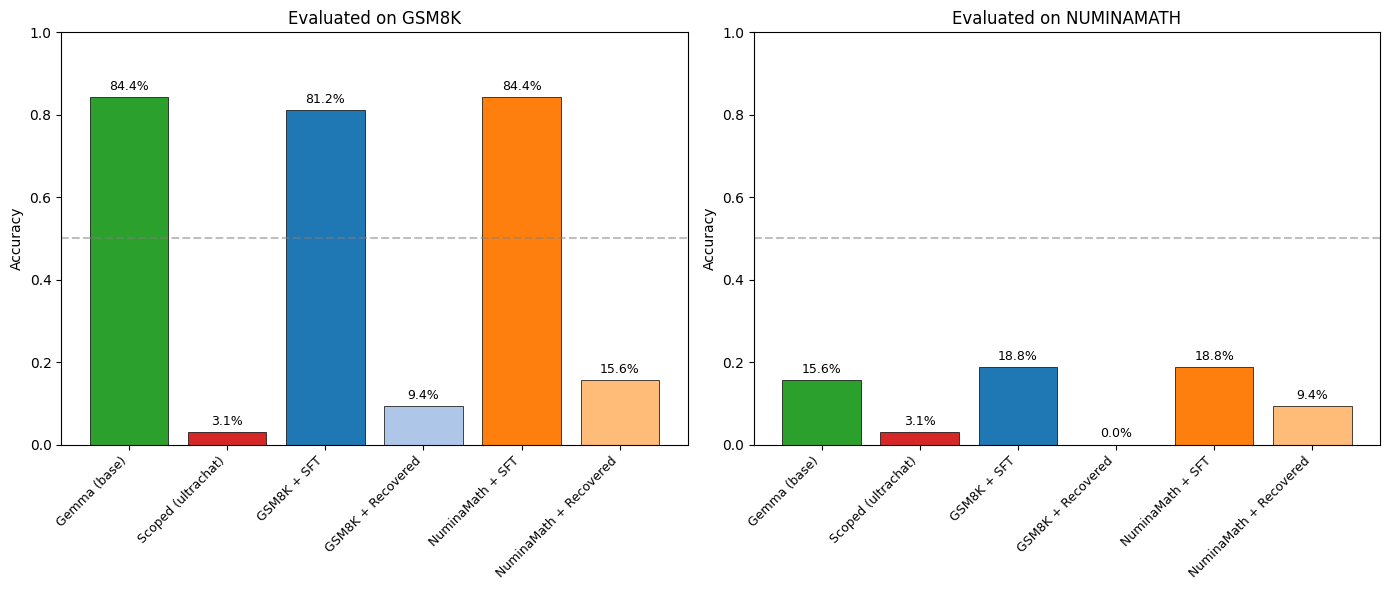

In [20]:
def plot_eval_results(results, eval_dataset, ax=None):
    """Plot bar chart for a specific evaluation dataset."""
    # Filter results for this evaluation dataset
    filtered = [r for r in results if r["dataset_evaluted_on"] == eval_dataset]
    
    # Sort by group order, then by accuracy within group
    def sort_key(r):
        group_idx = GROUP_ORDER.index(r["group"]) if r["group"] in GROUP_ORDER else len(GROUP_ORDER)
        return (group_idx, -r["accuracy"])
    filtered.sort(key=sort_key)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create bar positions
    x = np.arange(len(filtered))
    colors = [GROUP_COLORS.get(r["group"], "#999999") for r in filtered]
    accuracies = [r["accuracy"] for r in filtered]
    labels = [r["group"] for r in filtered]
    
    # Plot bars
    bars = ax.bar(x, accuracies, color=colors, edgecolor="black", linewidth=0.5)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f"{acc:.1%}", ha='center', va='bottom', fontsize=9)
    
    # Set labels and title
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Evaluated on {eval_dataset.upper()}")
    ax.set_ylim(0, 1.0)
    ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50%')
    
    # Create legend (unique groups only)
    # seen_groups = set()
    # legend_handles = []
    # legend_labels = []
    # for group in GROUP_ORDER:
    #     if group in [r["group"] for r in filtered] and group not in seen_groups:
    #         seen_groups.add(group)
    #         from matplotlib.patches import Patch
    #         legend_handles.append(Patch(facecolor=GROUP_COLORS[group], edgecolor='black'))
    #         legend_labels.append(group)
    # ax.legend(legend_handles, legend_labels, loc='upper right', fontsize=8)
    
    return ax

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Evaluated on GSM8K
plot_eval_results(results, "gsm8k", ax=axes[0])

# Plot 2: Evaluated on NuminaMath
plot_eval_results(results, "numinamath", ax=axes[1])

plt.tight_layout()
plt.savefig("math_eval_comparison.png", dpi=150, bbox_inches='tight')
plt.show()